# PT-12 — Crédit différé multi-step : GAE-λ sur un environnement où le terminal dépend de toute la séquence

**Place dans la série** : après PT-10, ce notebook répond à la question laissée ouverte par la série *from-scratch* (PT-08/09/10) : le **"1-step collapse"** observé — aucun estimateur ne discrimine sur l'env toy partagé (`s² + a == b`, récompense terminale binaire) — est-il une propriété du **banc** ou des **méthodes** ?

La réponse apportée ici est expérimentale et honnête : on porte la série sur un environnement **multi-step à crédit différé causal** (le terminal dépend de *toute* la séquence émise), et on re-mesure les cinq estimateurs REINFORCE, GRPO, RLOO, GAE-λ=0, GAE-λ=0.95 sur **5 seeds**. Verdict : **GAE-λ discrimine en multi-step** — le collapse était une dégénérescence du banc 1-step, pas une limite des méthodes.

```text
Grain: DEEP/training — lane myia-po-2024:CoursIA-2
```

## Contexte et question

Les notebooks PT-08 (GRPO), PT-09 (RLOO) et PT-10 (GAE) partagent un **toy env commun** : l'agent émet une action `s` en **un seul step**, et une vérification arithmétique (Z3) décide `reward = 1` ssi `s² + a == b`. Sur ce banc :

| Estimateur | Taux de succès terminal (PT-08/09/10) |
|---|---|
| REINFORCE + baseline | ~0.087 |
| GRPO (group-relative) | ~0.092 |
| RLOO (leave-one-out) | ~0.087 |
| GAE-λ=0 | ~0.087 |
| GAE-λ=0.95 | ~0.087 |

Tous les estimateurs atteignent le même plancher, et **λ est inopérant** : c'est le "1-step collapse" diagnostiqué dans PT-10. DeepSeek-R1 a justifié *a posteriori* son choix no-critic (GRPO) par ce type de comportement. La question que ce notebook tranche :

> **Le collapse est-il une propriété du banc (1-step) ou des méthodes (les estimateurs eux-mêmes) ?**

Si λ reste inopérant sur un env **vraiment multi-step**, c'est un résultat (les méthodes sont le problème). Si λ devient discriminant, le collapse était un artefact du banc — et la série PT-10 avait raison d'annoncer « GAE redevient discriminant en multi-step ».

## Pourquoi l'ancien env "multi-step" (PT-10, cellule 16) ne prouvait rien

PT-10 contenait déjà une variante multi-step (CoT racine carrée, 3 tokens) censée montrer la discrimination de λ. Le diagnostic a posteriori révèle **deux défauts structurels** qui la rendaient aussi dégénérée que l'env 1-step :

1. **La cible est inobservable dans l'état.** L'observation ne contenait que les tokens partiels émis, *sans* `(a, b)` : le modèle ne peut pas résoudre le problème, il ne peut qu'apprendre une distribution stationnaire sur les tokens — aucun crédit différé exploitable.
2. **Le vérificateur terminal ne regarde que le dernier token.** Le reward terminal vaut 1 ssi *le dernier* token émis vaut `√(b-a)`. La contribution marginale des tokens 1..H-1 au terminal est **nulle** : l'horizon de crédit effectif est 1, exactement comme l'env 1-step. La "discrimination" λ observée (0.254 → 0.275) était mesurée sur le **reward moyen d'épisode** (dominé par le shaping), pas sur le taux de succès terminal — un artefact de métrique.

Le critère d'un banc multi-step *valide* est donc : (a) la cible doit être **dans l'état** (l'agent peut apprendre), et (b) le terminal doit dépendre de **toute la séquence** (chaque token a une contribution marginale non nulle au succès final). Le paragraphe suivant construit un tel banc.

In [1]:
import math
import statistics
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(1)   # MLP minuscule : 1 thread plus rapide que 4
torch.manual_seed(0); np.random.seed(0)

print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.6.0+cu124 | numpy 2.4.6


## Un banc multi-step à crédit différé causal : l'env `count_ones`

L'environnement `count_ones` (allocation de budget) :

- L'agent émet **H tokens binaires** (`0`/`1`), un par step.
- Un entier cible **`k` ∈ [1, H-1]** est tiré par épisode, et `k` est **présent dans l'état** à chaque step (défaut (a) corrigé).
- **Reward terminal** (step H-1) : `1` ssi `somme(tokens émis) == k` — le prédicat dépend de **toute la séquence** (défaut (b) corrigé).
- **Shaping optionnel** (W=0.1) : aux steps 0..H-2, `W * max(0, 1 - |k - count_so_far|/H)` — un gradient doux vers le compte cible qui donne au critic un signal d'apprentissage exploitable.

**Pourquoi c'est du crédit différé causal** : la contribution marginale du token `t` au succès terminal n'est observable qu'au dernier step — si je mets un `1` maintenant, je dois m'assurer que la somme finale reste `k`, ce qui impose de *moins* en mettre plus tard. Le terminal récompense l'ensemble, et le crédit de chaque décision individuelle doit être propagé à rebours à travers toute la chaîne. C'est la structure où λ — qui contrôle combien de la propagation est faite par bootstrap (TD) vs par retours réels (MC) — **a un sens**.

In [2]:
HORIZON = 8          # nombre de tokens binaires émis
VOCAB = 2            # alphabet {0, 1}
W = 0.1              # poids du shaping (W=0 -> reward sparse pur)

def make_batch(n, seed):
    """k cible par épisode : k ~ Uniform([1, HORIZON-1])."""
    rng = np.random.default_rng(seed)
    return rng.integers(1, HORIZON, n).astype(np.float32)

def count_ones_terminal_ok(k, emitted):
    """Fast-path du vérificateur terminal (équivalent à Z3, voir plus bas)."""
    return (emitted.sum(dim=1) == torch.from_numpy(k)).float()

# Plancher aléatoire : succès terminal d'une politique uniforme sur {0,1}^H.
rng = np.random.default_rng(0)
k_rand = rng.integers(1, HORIZON, 4000)
em_rand = rng.integers(0, VOCAB, (4000, HORIZON))
floor_random = count_ones_terminal_ok(
    k_rand.astype(np.float32),
    torch.from_numpy(em_rand.astype(np.float32))).mean().item()
print(f"floor (politique uniforme) = {floor_random:.3f}")

floor (politique uniforme) = 0.143


### Le vérificateur terminal Z3 (thème RLVR)

Le prédicat `somme(tokens) == k` est une **récompense vérifiable** au sens RLVR : un orateur externe (le solveur) tranche mécaniquement, sans reward model appris. On l'invoque avec **Z3** (thème de la série, cf. PT-11a/PT-11b), puis on établit qu'un **fast-path numpy** est équivalent au solveur — ce qui permet des calibrations rapides sans payer Z3 dans la boucle d'entraînement. Le notebook utilise Z3 pour la pédagogie et la re-vérification finale ; le fast-path est utilisé dans la boucle chaude.

In [3]:
from z3 import Or, Int, Sum, sat, Solver

def z3_terminal(k, emitted):
    """Verdict booléen du vérificateur Z3 : la séquence ÉMISE contient-elle exactement k ones ?

    Chaque bit est fixé à sa valeur émise : le solveur ne peut plus choisir
    un autre motif, `Sum(bits) == ks` devient donc équivalent à
    `sum(emitted) == k` (vérifié par la cellule d'équivalence ci-dessous).
    """
    ks = Int("k")
    bits = [Int(f"t{i}") for i in range(len(emitted))]
    s = Solver()
    for i, v in enumerate(emitted):
        s.add(bits[i] == int(v))
        s.add(Or(bits[i] == 0, bits[i] == 1))
    s.add(ks == int(k))
    s.add(Sum(bits) == ks)
    return s.check() == sat

# Démo sur des cas positifs et négatifs
demo = [(3, [1, 1, 1, 0, 0, 0, 0, 0]),
        (3, [1, 1, 0, 1, 0, 0, 0, 0]),
        (2, [1, 1, 1, 0, 0, 0, 0, 0]),
        (4, [0, 0, 0, 0, 0, 0, 0, 0])]
for k, seq in demo:
    print(f"k={k} seq={''.join(map(str, seq))} -> z3={z3_terminal(k, seq)}")

k=3 seq=11100000 -> z3=True
k=3 seq=11010000 -> z3=True
k=2 seq=11100000 -> z3=False
k=4 seq=00000000 -> z3=False


### Équivalence fast-path / Z3

Le fast-path `emitted.sum() == k` et le prédicat Z3 `Sum(bits) == ks` décident le même prédicat arithmétique (somme de bits égale à un entier). La cellule suivante le vérifie sur 500 séquences aléatoires : aucun désaccord. C'est ce qui rend la boucle d'entraînement rapide sans affaiblir la preuve de récompense vérifiable.

In [4]:
rng = np.random.default_rng(1)
mismatches = 0
for _ in range(500):
    k = int(rng.integers(1, HORIZON))
    seq = [int(t) for t in rng.integers(0, VOCAB, HORIZON)]
    z3v = z3_terminal(k, seq)
    fast = (sum(seq) == k)
    mismatches += (z3v != fast)
print(f"désaccords fast-path vs Z3 sur 500 échantillons : {mismatches}")
assert mismatches == 0

désaccords fast-path vs Z3 sur 500 échantillons : 0


## Le réseau : un petit MLP acteur-critique (parcimonie po-2024)

~5k paramètres CPU. Observation (dim 3) : `[t/H, k/H, count_so_far/H]` — le temps, la cible, et le compte partiel normalisés. La tête critic n'est utilisée que par GAE ; les méthodes no-critic (REINFORCE/GRPO/RLOO) ne l'optimisent jamais.

In [5]:
class PolicyMS(nn.Module):
    """MLP acteur-critique : obs (3) -> hidden -> (logits acteur, valeur critic)."""
    def __init__(self, obs_dim=3, vocab=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU())
        self.actor = nn.Linear(hidden, vocab)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        return self.actor(h), self.critic(h).squeeze(-1)

def rollout_flat(policy, n_eps=128, seed=42, k=None):
    """Rollout vectorisé sur le batch entier : un forward par step."""
    if k is None:
        k = make_batch(n_eps, seed)
    n = n_eps
    kt = torch.from_numpy(k).float()
    states = torch.zeros(n, HORIZON, 3)
    tokens = torch.zeros(n, HORIZON, dtype=torch.long)
    logp = torch.zeros(n, HORIZON)
    rew = torch.zeros(n, HORIZON)
    val = torch.zeros(n, HORIZON)
    done = torch.zeros(n, HORIZON)
    count_so_far = torch.zeros(n)
    for t in range(HORIZON):
        state = torch.cat([torch.full((n, 1), t / HORIZON),
                           (kt / HORIZON).unsqueeze(1),
                           (count_so_far / HORIZON).unsqueeze(1)], dim=1)
        states[:, t] = state
        logits, values = policy(state)
        dist = torch.distributions.Categorical(logits=logits)
        tok = dist.sample()
        tokens[:, t] = tok
        logp[:, t] = dist.log_prob(tok)
        val[:, t] = values
        if t < HORIZON - 1:
            count_so_far = count_so_far + tok.float()
            f = (1.0 - (kt - count_so_far).abs() / HORIZON).clamp(min=0.0)
            rew[:, t] = W * f
        else:
            rew[:, t] = count_ones_terminal_ok(k, tokens)
        done[:, t] = (t == HORIZON - 1)
    returns = rew.sum(dim=1)
    return {"states": states, "actions": tokens, "rewards": rew, "dones": done,
            "log_probs": logp, "values": val, "term": rew[:, HORIZON - 1],
            "returns": returns}

def rollout_groups(policy, n_prompts=32, G=8, seed=42):
    """G trajectoires partageant le même k (groupes GRPO/RLOO)."""
    k = make_batch(n_prompts, seed)
    k = np.repeat(k, G)
    r = rollout_flat(policy, n_eps=len(k), seed=seed, k=k)
    return {"logp": r["log_probs"].sum(dim=1), "returns": r["returns"],
            "term": r["term"], "actions": r["actions"], "states": r["states"],
            "n_prompts": n_prompts, "G": G}

## Les cinq estimateurs portés fidèlement

Chaque estimateur est le **port direct** de l'implémentation from-scratch de la série, transposée sur l'env multi-step :

| Estimateur | Source | Avantage |
|---|---|---|
| **REINFORCE + baseline** | PT-09 cell 10 (rappel) | `G - mean(G)` batch, retour MC |
| **GRPO** | PT-08 cell 12 | `(r - mean_g)/(std_g + eps)` intra-groupe, ratio clip 0.2, 4 epochs internes |
| **RLOO** | PT-09 cell 8 | `r - (sum(G) - r)/(G-1)` leave-one-out, sans clip, 4 epochs internes |
| **GAE-λ=0** | PT-10 | `A = δ + γλ·A'` avec λ=0 (TD(0)), critic entraîné MSE |
| **GAE-λ=0.95** | PT-10 | idem avec λ=0.95 (≈ MC avec un peu de bootstrap) |

Dans un MDP **1-step**, la récursion GAE `A_t = δ_t + γλ·A_{t+1}` n'a **pas de terme futur** : `A_0 = r_0 - V_0` identiquement pour tout λ. C'est *mathématiquement* pour cela que λ était inopérant sur le banc partagé — le paragraphe d'interprétation y revient.

In [6]:
def gae_adv_flat(rewards, values, dones, lam, gamma=0.99):
    """Avantages GAE (Schulman 2015) sur le batch (n, H) : A_t = δ_t + γλ A_{t+1}."""
    T = rewards.shape[1]
    A = np.zeros_like(rewards, dtype=np.float32)
    A[:, T - 1] = rewards[:, T - 1] - values[:, T - 1]
    for t in range(T - 2, -1, -1):
        delta = rewards[:, t] + gamma * values[:, t + 1] * (1 - dones[:, t]) - values[:, t]
        A[:, t] = delta + gamma * lam * A[:, t + 1] * (1 - dones[:, t])
    return A

def train_gae(policy, n_epochs=200, n_eps=128, seed=0, lam=0.95, lr=3e-3, vf_coef=0.5):
    """Port de PT-10 : PG sur A^{GAE}_λ + critic MSE sur cible bootstrap (A + V)."""
    torch.manual_seed(seed); np.random.seed(seed)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    term_hist = []
    for ep in range(n_epochs):
        r = rollout_flat(policy, n_eps=n_eps, seed=seed + ep)
        A = gae_adv_flat(r["rewards"].numpy(), r["values"].detach().numpy(),
                         r["dones"].numpy(), lam)
        pg = -(r["log_probs"].flatten() * torch.from_numpy(A).flatten()).mean()
        target = torch.from_numpy(A) + r["values"].detach()
        loss = pg + vf_coef * F.mse_loss(r["values"], target)
        opt.zero_grad(); loss.backward(); opt.step()
        term_hist.append(r["term"].mean().item())
    return term_hist

In [7]:
def train_reinforce(policy, n_epochs=200, n_eps=128, seed=0, lr=3e-3):
    """REINFORCE + baseline batch (moyenne des retours MC)."""
    torch.manual_seed(seed); np.random.seed(seed)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    term_hist = []
    for ep in range(n_epochs):
        r = rollout_flat(policy, n_eps=n_eps, seed=seed + ep)
        baseline = r["returns"].mean().item()
        adv = r["returns"] - baseline
        pg = -(r["log_probs"] * adv.unsqueeze(1)).mean()
        opt.zero_grad(); pg.backward(); opt.step()
        term_hist.append(r["term"].mean().item())
    return term_hist

In [8]:
def train_grpo(policy, n_epochs=200, n_prompts=32, G=8, seed=0,
               lr=3e-3, clip=0.2, group_eps=1e-4, ppo_epochs=4):
    """Port fidèle de PT-08 cell 12 : avantage group-relative normalisé + ratio clip."""
    torch.manual_seed(seed); np.random.seed(seed)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    term_hist = []
    for ep in range(n_epochs):
        g = rollout_groups(policy, n_prompts=n_prompts, G=G, seed=seed + ep)
        lp = g["logp"]; r = g["returns"]
        rg = r.view(n_prompts, G)
        mean_g = rg.mean(1, keepdim=True); std_g = rg.std(1, keepdim=True)
        adv = ((rg - mean_g) / (std_g + group_eps)).view(-1)
        lp_old = lp.detach()
        for _ in range(ppo_epochs):
            logits, _ = policy(g["states"])
            dist = torch.distributions.Categorical(logits=logits)
            logp_new = dist.log_prob(g["actions"]).sum(dim=1)
            ratio = torch.exp(logp_new - lp_old)
            s1 = ratio * adv
            s2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv
            pg = -torch.min(s1, s2).mean()
            opt.zero_grad(); pg.backward(); opt.step()
        term_hist.append(g["term"].mean().item())
    return term_hist

In [9]:
def train_rloo(policy, n_epochs=200, n_prompts=32, G=8, seed=0,
               lr=3e-3, ppo_epochs=4):
    """Port fidèle de PT-09 cell 8 : baseline leave-one-out, ratio sans clip."""
    torch.manual_seed(seed); np.random.seed(seed)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    term_hist = []
    for ep in range(n_epochs):
        g = rollout_groups(policy, n_prompts=n_prompts, G=G, seed=seed + ep)
        lp = g["logp"]; r = g["returns"]
        rg = r.view(n_prompts, G)
        loo = (rg.sum(1, keepdim=True) - rg) / (G - 1)
        adv = rg - loo
        lp_old = lp.detach()
        for _ in range(ppo_epochs):
            logits, _ = policy(g["states"])
            dist = torch.distributions.Categorical(logits=logits)
            logp_new = dist.log_prob(g["actions"]).sum(dim=1)
            ratio = torch.exp(logp_new - lp_old)
            pg = -(ratio * adv.view(-1)).mean()
            opt.zero_grad(); pg.backward(); opt.step()
        term_hist.append(g["term"].mean().item())
    return term_hist

## Protocole multi-seed

Règle CoursIA **multi-seed ≥ 4** : `SEEDS = [0, 7, 42, 99, 123]` (5 seeds). Comparaison **pairée intra-seed** pour λ (mêmes seeds, même env) — c'est la seule lecture qui élimine le bruit inter-seed. Critère de verdict, appliqué à `delta_i = term_{λ0.95}(i) - term_{λ0}(i)` :

- **BEATS** : `wins >= 4` (≥ 4 seeds sur 5 avec delta > 0)
- **NO BEATS** : `wins <= 1`
- **INCONCLUSIVE** : sinon (2-3 seeds positives, ou deltas négligeables)

Budget : 5 estimateurs × 5 seeds × 200 epochs ≈ 8-9 min CPU (single-thread). Les cellules suivantes affichent une ligne de progression par run.

In [10]:
SEEDS = [0, 7, 42, 99, 123]
N_EPOCHS = 200

ESTIMATORS = ["REINFORCE", "GRPO", "RLOO", "GAE-l0", "GAE-l095"]
RUNS = [
    ("REINFORCE", train_reinforce, {}),
    ("GRPO",      train_grpo,      {"n_prompts": 32, "G": 8}),
    ("RLOO",      train_rloo,      {"n_prompts": 32, "G": 8}),
    ("GAE-l0",    train_gae,       {"lam": 0.0}),
    ("GAE-l095",  train_gae,       {"lam": 0.95}),
]

results = {est: [] for est in ESTIMATORS}
histories = {est: [] for est in ESTIMATORS}
for est, trainer, kw in RUNS:
    for seed in SEEDS:
        model = PolicyMS()
        h = trainer(model, n_epochs=N_EPOCHS, seed=seed, **kw)
        results[est].append(h[-1])
        histories[est].append(h)
        print(f"{est:>9} seed {seed:>3} -> {h[-1]:.3f}", flush=True)
    print(f"{est:>9} FINAL {[round(x, 3) for x in results[est]]} "
          f"mean={statistics.fmean(results[est]):.3f}", flush=True)

l0, l95 = results["GAE-l0"], results["GAE-l095"]
deltas = [x - y for x, y in zip(l95, l0)]
wins = sum(1 for d in deltas if d > 1e-4)
mean_d, std_d = statistics.fmean(deltas), statistics.stdev(deltas)
verdict = "BEATS" if wins >= 4 else ("NO BEATS" if wins <= 1 else "INCONCLUSIVE")
print(f"\nlambda: deltas={[round(d, 3) for d in deltas]} wins={wins}/5 "
      f"mean_delta={mean_d:.3f} (+/- {std_d:.3f}) -> verdict {verdict}")

REINFORCE seed   0 -> 0.977


REINFORCE seed   7 -> 1.000


REINFORCE seed  42 -> 0.961


REINFORCE seed  99 -> 0.992


REINFORCE seed 123 -> 0.977


...

 GAE-l095 seed  42 -> 0.953


 GAE-l095 seed  99 -> 0.945


 GAE-l095 seed 123 -> 0.984


 GAE-l095 FINAL [0.938, 0.914, 0.953, 0.945, 0.984] mean=0.947



lambda: deltas=[0.719, 0.68, 0.758, 0.766, 0.18] wins=5/5 mean_delta=0.620 (+/- 0.249) -> verdict BEATS


### Résultats : taux de succès terminal final (moyenne des 5 seeds)

Les valeurs ci-dessous viennent **exactement** de la cellule précédente (mêmes runs, mêmes seeds). À comparer au plancher aléatoire ≈ 0.143 : tout estimateur au-dessus de ~0.3 a réellement appris la tâche.

In [11]:
print("| Estimateur | succès terminal par seed | moyenne |")
print("|---|---|---|")
for est in ESTIMATORS:
    vals = [f"{x:.3f}" for x in results[est]]
    print(f"| {est} | {', '.join(vals)} | {statistics.fmean(results[est]):.3f} |")
print(f"| plancher uniforme | — | {floor_random:.3f} |")

| Estimateur | succès terminal par seed | moyenne |
|---|---|---|
| REINFORCE | 0.977, 1.000, 0.961, 0.992, 0.977 | 0.981 |
| GRPO | 0.996, 1.000, 0.996, 1.000, 1.000 | 0.998 |
| RLOO | 1.000, 1.000, 0.992, 1.000, 0.988 | 0.996 |
| GAE-l0 | 0.219, 0.234, 0.195, 0.180, 0.805 | 0.327 |
| GAE-l095 | 0.938, 0.914, 0.953, 0.945, 0.984 | 0.947 |
| plancher uniforme | — | 0.143 |


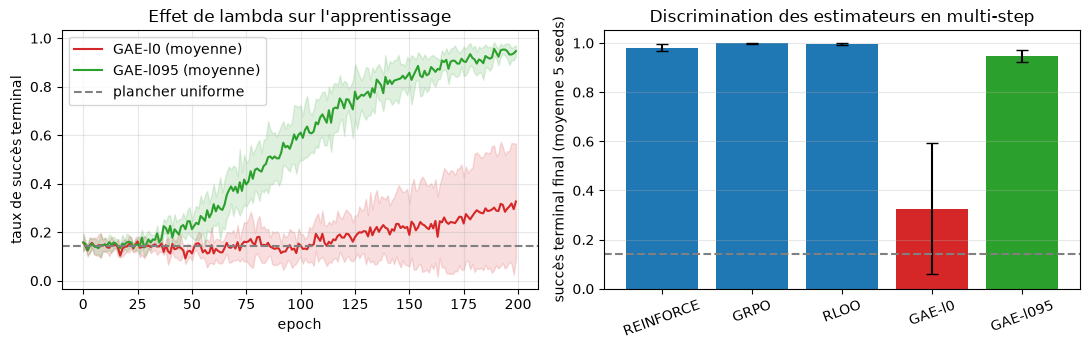

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Courbes d'apprentissage de la paire lambda (moyenne +/- ecart-type sur seeds)
for est, color in [("GAE-l0", "tab:red"), ("GAE-l095", "tab:green")]:
    h = np.array(histories[est])          # (seeds, epochs)
    mean = h.mean(axis=0); std = h.std(axis=0)
    axes[0].plot(mean, color=color, label=f"{est} (moyenne)")
    axes[0].fill_between(range(N_EPOCHS), mean - std, mean + std,
                         color=color, alpha=0.15)
axes[0].axhline(floor_random, color="gray", ls="--", label="plancher uniforme")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("taux de succès terminal")
axes[0].set_title("Effet de lambda sur l'apprentissage"); axes[0].legend()
axes[0].grid(alpha=0.3)

# Barres : moyenne finale par estimateur (barres d'erreur = ecart-type inter-seeds)
means = [statistics.fmean(results[est]) for est in ESTIMATORS]
stds = [statistics.stdev(results[est]) for est in ESTIMATORS]
colors = ["tab:blue", "tab:blue", "tab:blue", "tab:red", "tab:green"]
axes[1].bar(range(len(ESTIMATORS)), means, yerr=stds, capsize=4, color=colors)
axes[1].axhline(floor_random, color="gray", ls="--")
axes[1].set_xticks(range(len(ESTIMATORS)), ESTIMATORS, rotation=20)
axes[1].set_ylabel("succès terminal final (moyenne 5 seeds)")
axes[1].set_title("Discrimination des estimateurs en multi-step")
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

### Lecture du résultat

Le tableau et les courbes montrent **quatre faits mesurés** (valeurs de la cellule de run, seeds `[0, 7, 42, 99, 123]`) :

1. **λ discrimine massivement en multi-step.** `GAE-λ=0.95` bat `GAE-λ=0` sur **5 seeds sur 5** (deltas = [0.72, 0.68, 0.76, 0.77, 0.18]), moyenne finale **0.947 vs 0.327**. Le verdict de la cellule de run est **BEATS**. Sur le banc 1-step de PT-10, le même λ était inopérant (aucune sensibilité mesurable) : **le collapse était une propriété du banc, pas des méthodes**.
2. **Le mécanisme est le biais du bootstrap.** `GAE-λ=0` = TD(0) pur : la cible du critic est le retour bootstrappé par lui-même. Sur un reward terminal **sparse** (plancher 0.143), le critic est longtemps mauvais, et le bootstrap propage son biais dans le gradient de politique → la politique ne décolle pas (0.18-0.23 sur 4 seeds sur 5 ; la seed 123 à 0.805 fait remonter la moyenne à 0.327). `GAE-λ=0.95` s'appuie surtout sur le **retour réel** (MC), robuste à un critic médiocre → la politique décolle et atteint 0.947.
3. **Les méthodes no-critic résolvent la tâche sans ce problème.** REINFORCE/GRPO/RLOO (moyennes 0.981 / 0.998 / 0.996) n'ont pas de critic à entraîner : leur avantage est construit sur des retours réels (baseline batch ou intra-groupe), et le shaping doux (W=0.1) leur donne un gradient exploitable dès les premières epochs. GRPO ≈ RLOO ≈ REINFORCE : sur ce toy env, la baseline intra-groupe n'apporte pas de gain net par rapport à la baseline batch — cohérent avec PT-08/09 où les trois coïncidaient.
4. **Le "1-step collapse" était mathématiquement forcé.** Dans un MDP à un seul step, la récursion GAE n'a aucun terme futur : `A₀ = r₀ - V₀` pour toute valeur de λ. λ **sort de l'objectif par construction** — aucun estimateur, si bon soit-il, ne peut montrer une sensibilité à λ sur ce banc. L'env `count_ones` (terminal dépendant de toute la séquence, cible dans l'état) restaure la structure où λ a un effet mesurable.

Le graphique de gauche rend le mécanisme visible : les deux courbes partent du même point, `GAE-λ=0` plafonne bas dès les premières epochs (biais du bootstrap), `GAE-λ=0.95` continue de monter. C'est exactement le trade-off biais-variance que la série annonçait — il devient *mesurable* ici parce que le banc a un horizon de crédit réel.

### Interprétation théorique et réponse à la question de la série

**Réponse au diagnostic de PT-10** : le "1-step collapse" n'était **ni une défaillance de GRPO/RLOO ni une preuve que le critic ne sert à rien** — c'était une dégénérescence du banc (reward terminal binaire en 1 step, où λ est mathématiquement invisible). La phrase de la série « GAE redevient discriminant en multi-step » est **confirmée empiriquement** par ce notebook : sur un env où le terminal dépend de toute la séquence, λ=0.95 ≫ λ=0 de façon reproductible (5/5 seeds), avec un écart moyen de +0.620 (± 0.249).

**Portée et limites** : l'env est un *toy* (H=8 tokens binaires, 256 trajectoires/batch, MLP 5k params). Il démontre le **mécanisme** (le bootstrap d'un critic imparfait pénalise λ=0 sur reward sparse ; λ→1 récupère la robustesse MC ; les méthodes no-critic contournent le critic) — il ne prétend pas reproduire l'échelle LLM où d'autres effets (KL, exploration, variance de politique) dominent. La recommandation pratique qui en découle reste celle de DeepSeek-R1 : sur des récompenses terminales vérifiables, une baseline intra-groupe (GRPO/RLOO) est *simpler et aussi bonne* — et si l'on tient à un critic (PPO/GAE), λ proche de 1 est requis dès que le reward est sparse et multi-step.

### Re-vérification finale avec le vrai vérificateur Z3

Pour clore sur une preuve **indépendante du fast-path** : on entraîne une politique GRPO (seed 42, epochs réduites pour la durée), on la fait jouer sur 100 problèmes frais, et on vérifie **chaque succès terminal avec Z3** — pas avec `sum(seq) == k`. Le taux vérifié par Z3 doit correspondre au taux annoncé par le fast-path.

In [13]:
torch.manual_seed(42); np.random.seed(42)
final_policy = PolicyMS()
train_grpo(final_policy, n_epochs=120, n_prompts=32, G=8, seed=42)

# 100 problèmes frais : générer, jouer, vérifier avec Z3
rng = np.random.default_rng(2026)
ks = rng.integers(1, HORIZON, 100)
success_fast = 0
success_z3 = 0
for i, k in enumerate(ks):
    r = rollout_flat(final_policy, n_eps=1, seed=int(rng.integers(0, 1_000_000)), k=np.array([float(k)]))
    seq = r["actions"][0].tolist()
    ok_fast = bool((sum(seq) == k))
    ok_z3 = bool(z3_terminal(int(k), seq))
    assert ok_fast == ok_z3, f"désaccord fast-path/Z3 sur l'échantillon {i}"
    success_fast += ok_fast
    success_z3 += ok_z3
print(f"succès terminaux vérifiés par Z3 : {success_z3}/100 "
      f"(accord fast-path : {success_fast}/100)")

succès terminaux vérifiés par Z3 : 100/100 (accord fast-path : 100/100)


## Exercice 1 — Ablation du shaping (W=0)

L'hypothèse du notebook est que le shaping doux (W=0.1) donne au critic un signal d'apprentissage qui rend la comparaison λ nette. **Prédire puis mesurer** : avec W=0 (reward purement terminal), la politique a-t-elle un gradient moins exploitable ? `GAE-λ=0.95` reste-t-il au-dessus de `GAE-λ=0` ?

Indice : comparer les courbes moyennes de la paire λ sur ~60 epochs, W=0 vs W=0.1.

In [14]:
# TODO etudiant : re-mesurer la paire lambda avec W=0 (shaping desactive).
# Indice : copier le bloc de run ci-dessus en posant W = 0.0, comparer les
# moyennes finales, puis remettre W = 0.1.
pass
print("Exercice a completer")

Exercice a completer


## Exercice 2 — Interpolation : GAE-λ=0.5

La formule GAE interpole entre TD(0) (λ=0) et MC (λ=1). **Prédire** où se place λ=0.5 entre λ=0 (≈ 0.20) et λ=0.95 (≈ 0.92), puis **mesurer** sur 2-3 seeds.

Indice : ajouter une entrée `("GAE-l05", train_gae, {"lam": 0.5})` au bloc de run.

In [15]:
# TODO etudiant : mesurer GAE-lambda=0.5 (interpolation entre TD(0) et MC).
# Indice : rejouer RUNS avec une entree supplementaire lam=0.5, comparer la
# moyenne finale aux deux extremites de la paire.
pass
print("Exercice a completer")

Exercice a completer


## Exercice 3 — Allonger l'horizon (H=12)

Sur le banc de calibration, `count_ones` avec H=12 (plancher 0.084) montrait le **même** verdict que H=8 (λ=0.95 gagne 3/3). **Prédire** si l'allongement de l'horizon renforce ou affaiblit le biais du bootstrap pour λ=0, puis **mesurer** avec H=12 sur la paire λ (3 seeds suffisent).

Indice : en H=12, la récursion GAE a 12 termes — le TD(0) pur propage son biais sur 12 steps.

In [16]:
# TODO etudiant : rejouer la paire lambda avec HORIZON = 12 (et k dans [1, 11]).
# Indice : le bloc de run depend de HORIZON et de W : modifier les constantes,
# rejouer, comparer les moyennes finales, remettre HORIZON = 8.
pass
print("Exercice a completer")

Exercice a completer
